# HPC Usage Statistics: Infrastructure Perspective

This notebook visualises HPC cluster usage from an **infrastructure perspective**, focusing on **weighted efficiency metrics**. Weighted efficiency answers: "How efficiently are allocated resources being used overall?" — larger jobs contribute more because they consume more cluster capacity.

**Use this notebook for:**
- Capacity planning and resource allocation decisions
- Identifying which faculties/users have the largest impact on cluster utilisation
- Quantifying total resource waste in absolute terms

For a user-focused view (average efficiency, where each job counts equally), see `visualisation_users.ipynb`.

**Sections:**
1. [Overview](#1.-Overview) - Basic resource usage metrics by faculty
2. [Global Stats](#2.-Global-Stats) - Key metrics at a glance
3. [Detailed Analysis](#3.-Detailed-Analysis) - Comprehensive charts and comparisons
4. [Correlation Analysis](#4.-Correlation-Analysis) - Relationships between metrics
5. [Technical Appendix](#5.-Technical-Appendix) - Methodology and raw data

In [1]:
# Setup and imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

# --- Edit per run ---
# Date range of the CSVs to load (None = use the most recent files in RESULTS_DIR)
DATE_FILTER = "2025-07-01_2025-12-31"
RESULTS_DIR = "../results/data"

# --- Plot style (aligned with blog_2026-02_sustainability.ipynb, the style ground truth) ---
sns.set_theme(style='white')
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.titlepad': 14,
    'axes.labelpad': 8,
})

# Shared colour palette (matches the blog notebook)
C_CPU  = '#2196F3'
C_MEM  = '#4CAF50'
C_TIME = '#9C27B0'
C_OK   = '#4CAF50'
C_FAIL = '#F44336'
C_CAN  = '#9E9E9E'

def approx(n, sf=2):
    """Round to sf significant figures and add a k/M suffix."""
    if n == 0:
        return '0'
    mag = 10 ** (len(str(abs(int(n)))) - sf)
    rounded = round(n / mag) * mag
    if rounded >= 1_000_000:
        val = rounded / 1_000_000
        return f'~{val:.0f}M' if val == int(val) else f'~{val:.1f}M'
    if rounded >= 1_000:
        val = rounded / 1_000
        return f'~{val:.0f}k' if val == int(val) else f'~{val:.1f}k'
    return f'~{rounded}'

def fmt_count(x, _):
    """Format axis tick counts: k for thousands, M for millions."""
    if abs(x) >= 1_000_000:
        return f'{x / 1_000_000:.1f}M'
    elif abs(x) >= 1_000:
        return f'{x / 1_000:.0f}k'
    else:
        return f'{x:.0f}'

COUNT_FMT = mticker.FuncFormatter(fmt_count)

In [2]:
# Load data
import glob as _glob

if DATE_FILTER:
    faculty_files = sorted(_glob.glob(f'{RESULTS_DIR}/{DATE_FILTER}_hpc_stats_output.csv'))
    job_files = sorted(_glob.glob(f'{RESULTS_DIR}/{DATE_FILTER}_job_level_metrics.csv'))
else:
    faculty_files = sorted(_glob.glob(f'{RESULTS_DIR}/*_hpc_stats_output.csv'))
    job_files = sorted(_glob.glob(f'{RESULTS_DIR}/*_job_level_metrics.csv'))

if not faculty_files:
    raise FileNotFoundError(
        f'No matching *_hpc_stats_output.csv found in {RESULTS_DIR}'
        + (f' for DATE_FILTER={DATE_FILTER!r}' if DATE_FILTER else ''))
if not job_files:
    raise FileNotFoundError(
        f'No matching *_job_level_metrics.csv found in {RESULTS_DIR}'
        + (f' for DATE_FILTER={DATE_FILTER!r}' if DATE_FILTER else ''))

FACULTY_STATS_PATH = faculty_files[-1]  # most recent
JOB_LEVEL_PATH = job_files[-1]

# Extract date range from CSV comment line, or fall back to filename
def _read_date_range(path):
    import re as _re
    with open(path) as f:
        first_line = f.readline().strip()
    if first_line.startswith('# date_range:'):
        return first_line.split(':', 1)[1].strip()
    m = _re.search(r'(\d{4}-\d{2}-\d{2})_(\d{4}-\d{2}-\d{2})_', path)
    if m:
        return f'{m.group(1)} to {m.group(2)}'
    return 'unknown'

DATE_RANGE = _read_date_range(FACULTY_STATS_PATH)
print(f'Date range: {DATE_RANGE}')
print(f'Faculty stats: {FACULTY_STATS_PATH}')
print(f'Job-level data: {JOB_LEVEL_PATH}')

df = pd.read_csv(FACULTY_STATS_PATH, comment='#')
df['faculty'] = df['faculty'].str.strip('"')
df_faculties = df[df['faculty'] != 'all'].copy()
df_global = df[df['faculty'] == 'all'].copy()

# Convert NULL strings to NaN
df_faculties = df_faculties.replace('NULL', np.nan)
for col in df_faculties.columns:
    if col != 'faculty':
        df_faculties[col] = pd.to_numeric(df_faculties[col], errors='coerce')

# Faculty name mapping: merge historically different names for the same faculty
FACULTY_MERGE = {
    "Faculty of Life Sciences and Medicine": "Faculty of Life Sciences & Medicine",
    "IoPPN": "Institute of Psychiatry, Psychology & Neuroscience",
    "Dentistry, Oral & Craniofacial Sciences": "Faculty of Dentistry, Oral & Craniofacial Sciences",
    "Social Science & Public Policy": "Faculty of Social Science & Public Policy",
}

df_faculties['faculty'] = df_faculties['faculty'].replace(FACULTY_MERGE)

# --- Re-aggregate after faculty merge ---
df_faculties['_cpu_eff_denom'] = np.where(
    df_faculties['weighted_cpu_eff_req'] > 0,
    df_faculties['total_cpu_sec'] * 100 / df_faculties['weighted_cpu_eff_req'], 0)
df_faculties['_cpu_eff_alloc_denom'] = np.where(
    df_faculties['weighted_cpu_eff_alloc'] > 0,
    df_faculties['total_cpu_sec'] * 100 / df_faculties['weighted_cpu_eff_alloc'], 0)
df_faculties['_time_eff_denom'] = np.where(
    df_faculties['weighted_time_eff'] > 0,
    df_faculties['total_elapsed_sec'] * 100 / df_faculties['weighted_time_eff'], 0)

sum_cols = [
    'job_count', 'job_count_success', 'job_count_failed',
    'count_timeout', 'count_out_of_memory',
    'total_elapsed_sec', 'total_cpu_sec', 'total_user_cpu_sec', 'total_sys_cpu_sec',
    'total_maxrss_bytes', 'total_reqmem_bytes',
    'total_reqcpus', 'total_nodes', 'total_wait_sec',
    '_cpu_eff_denom', '_cpu_eff_alloc_denom', '_time_eff_denom',
]

# Include total_allocmem_bytes if present (new column)
if 'total_allocmem_bytes' in df_faculties.columns:
    sum_cols.append('total_allocmem_bytes')

avg_eff_cols = ['avg_cpu_eff_req', 'avg_cpu_eff_alloc', 'avg_mem_eff', 'avg_time_eff']
if 'avg_mem_eff_alloc' in df_faculties.columns:
    avg_eff_cols.append('avg_mem_eff_alloc')
for col in avg_eff_cols:
    df_faculties[f'_{col}_wsum'] = df_faculties[col].fillna(0) * df_faculties['job_count']
    sum_cols.append(f'_{col}_wsum')

df_faculties = df_faculties.groupby('faculty')[sum_cols].sum().reset_index()

# Recompute derived metrics
df_faculties['avg_elapsed_sec'] = df_faculties['total_elapsed_sec'] / df_faculties['job_count']
df_faculties['avg_cpu_sec'] = df_faculties['total_cpu_sec'] / df_faculties['job_count']
df_faculties['avg_maxrss_bytes'] = df_faculties['total_maxrss_bytes'] / df_faculties['job_count']
df_faculties['avg_reqmem_bytes'] = df_faculties['total_reqmem_bytes'] / df_faculties['job_count']
df_faculties['avg_reqcpus'] = df_faculties['total_reqcpus'] / df_faculties['job_count']
df_faculties['avg_wait_sec'] = df_faculties['total_wait_sec'] / df_faculties['job_count']

df_faculties['weighted_cpu_eff_req'] = np.where(
    df_faculties['_cpu_eff_denom'] > 0,
    df_faculties['total_cpu_sec'] / df_faculties['_cpu_eff_denom'] * 100, np.nan)
df_faculties['weighted_cpu_eff_alloc'] = np.where(
    df_faculties['_cpu_eff_alloc_denom'] > 0,
    df_faculties['total_cpu_sec'] / df_faculties['_cpu_eff_alloc_denom'] * 100, np.nan)
df_faculties['weighted_mem_eff'] = np.where(
    df_faculties['total_reqmem_bytes'] > 0,
    df_faculties['total_maxrss_bytes'] / df_faculties['total_reqmem_bytes'] * 100, np.nan)
if 'total_allocmem_bytes' in df_faculties.columns:
    df_faculties['weighted_mem_eff_alloc'] = np.where(
        df_faculties['total_allocmem_bytes'] > 0,
        df_faculties['total_maxrss_bytes'] / df_faculties['total_allocmem_bytes'] * 100, np.nan)
df_faculties['weighted_time_eff'] = np.where(
    df_faculties['_time_eff_denom'] > 0,
    df_faculties['total_elapsed_sec'] / df_faculties['_time_eff_denom'] * 100, np.nan)

for col in avg_eff_cols:
    df_faculties[col] = df_faculties[f'_{col}_wsum'] / df_faculties['job_count']


df_faculties = df_faculties.drop(columns=[c for c in df_faculties.columns if c.startswith('_')])
df_plot = df_faculties.sort_values('job_count', ascending=True)

print(f"Loaded aggregate data: {len(df_faculties)} faculties")
print(f"Total jobs: {df_faculties['job_count'].sum():,}")

Date range: 2025-07-01 to 2025-12-31
Faculty stats: ../results/data/2025-07-01_2025-12-31_hpc_stats_output.csv
Job-level data: ../results/data/2025-07-01_2025-12-31_job_level_metrics.csv
Loaded aggregate data: 13 faculties
Total jobs: 3,717,485


In [3]:
# Faculty abbreviations for plot labels (consistent with the blog-post notebook)
FACULTY_ABBREV = {
    'Faculty of Social Science & Public Policy':                'SSPP',
    'Faculty of Natural, Mathematical & Engineering Sciences':  'NMES',
    'Faculty of Dentistry, Oral & Craniofacial Sciences':       'DOCS',
    'Faculty of Life Sciences & Medicine':                      'LSM',
    'Institute of Psychiatry, Psychology & Neuroscience':       'IoPPN',
    'Faculty of Arts & Humanities':                             'AH',
    'Research Management & Innovation':                         'RMI',
    "King's Business School":                                   'KBS',
    'Students & Education':                                     'SE',
    'The Dickson Poon School of Law':                           'DPSL',
    'IT':                                                       'IT',
    'Other':                                                    'Other',
    'unknown':                                                  'N/A',
}

df_faculties['faculty_short'] = df_faculties['faculty'].map(FACULTY_ABBREV).fillna(df_faculties['faculty'])
FACULTY_SHORT = dict(zip(df_faculties['faculty'], df_faculties['faculty_short']))
df_plot = df_faculties.sort_values('job_count', ascending=True)

# Try to load per-job data
try:
    df_jobs = pd.read_csv(JOB_LEVEL_PATH, comment='#')
    if 'faculty' in df_jobs.columns:
        df_jobs['faculty'] = df_jobs['faculty'].str.strip('"')
        df_jobs['faculty'] = df_jobs['faculty'].replace(FACULTY_MERGE)
        df_jobs['faculty_short'] = df_jobs['faculty'].map(FACULTY_SHORT).fillna(df_jobs['faculty'])
    df_jobs = df_jobs.replace('NULL', np.nan)
    for col in ['cpu_eff_req', 'mem_eff', 'time_eff', 'wait_sec', 'elapsed_sec']:
        if col in df_jobs.columns:
            df_jobs[col] = pd.to_numeric(df_jobs[col], errors='coerce')
    HAS_JOB_DATA = True
    print(f"Loaded per-job data: {len(df_jobs):,} jobs")
except FileNotFoundError:
    HAS_JOB_DATA = False
    print(f"Note: {JOB_LEVEL_PATH} not found. Some analyses will be skipped.")

Loaded per-job data: 2,916,255 jobs


---
# 1. Overview

Basic resource usage metrics by faculty.

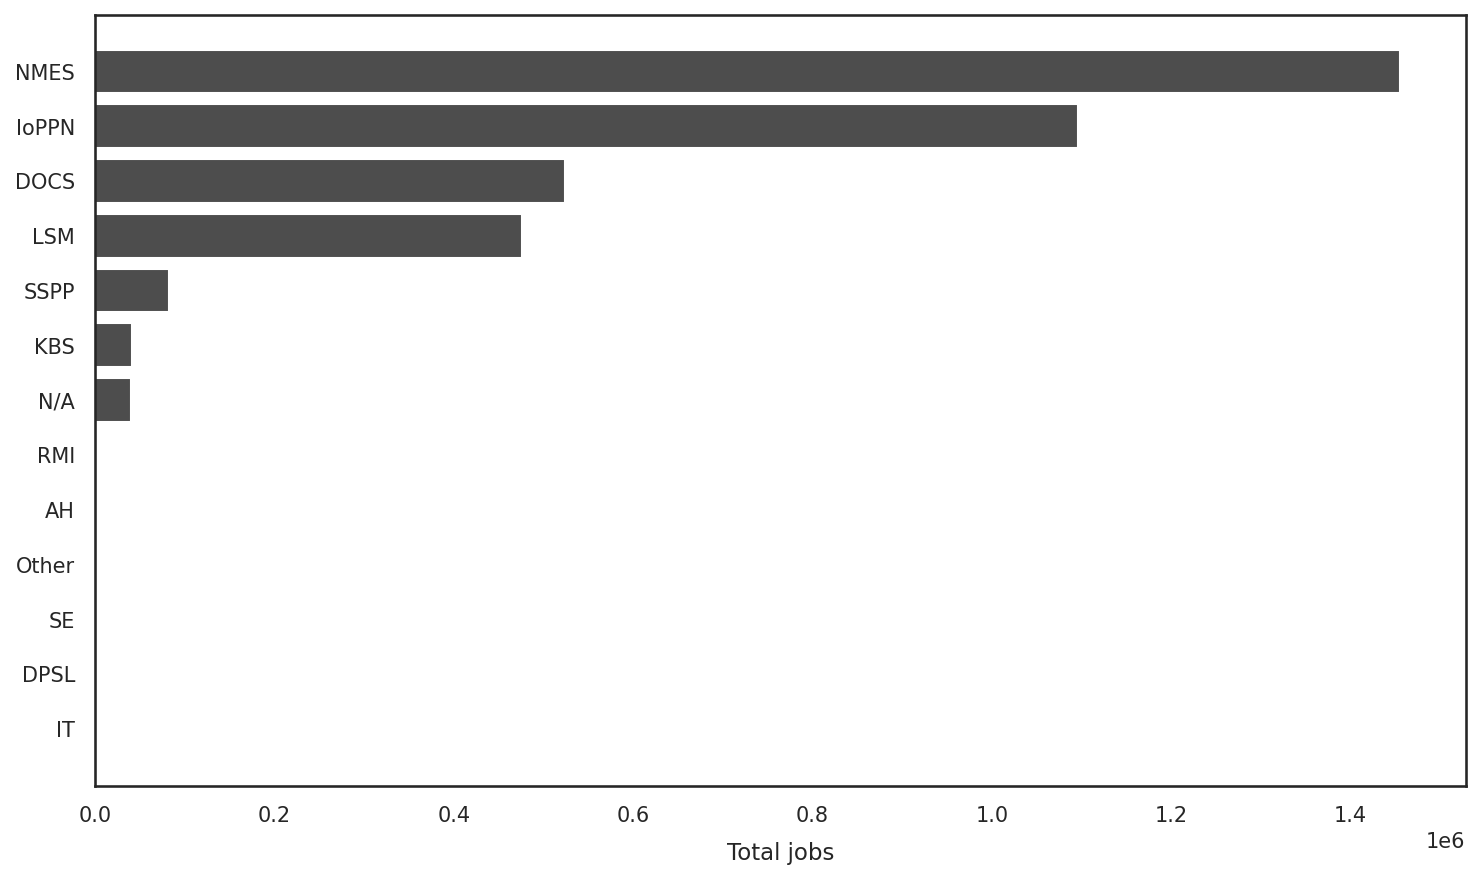

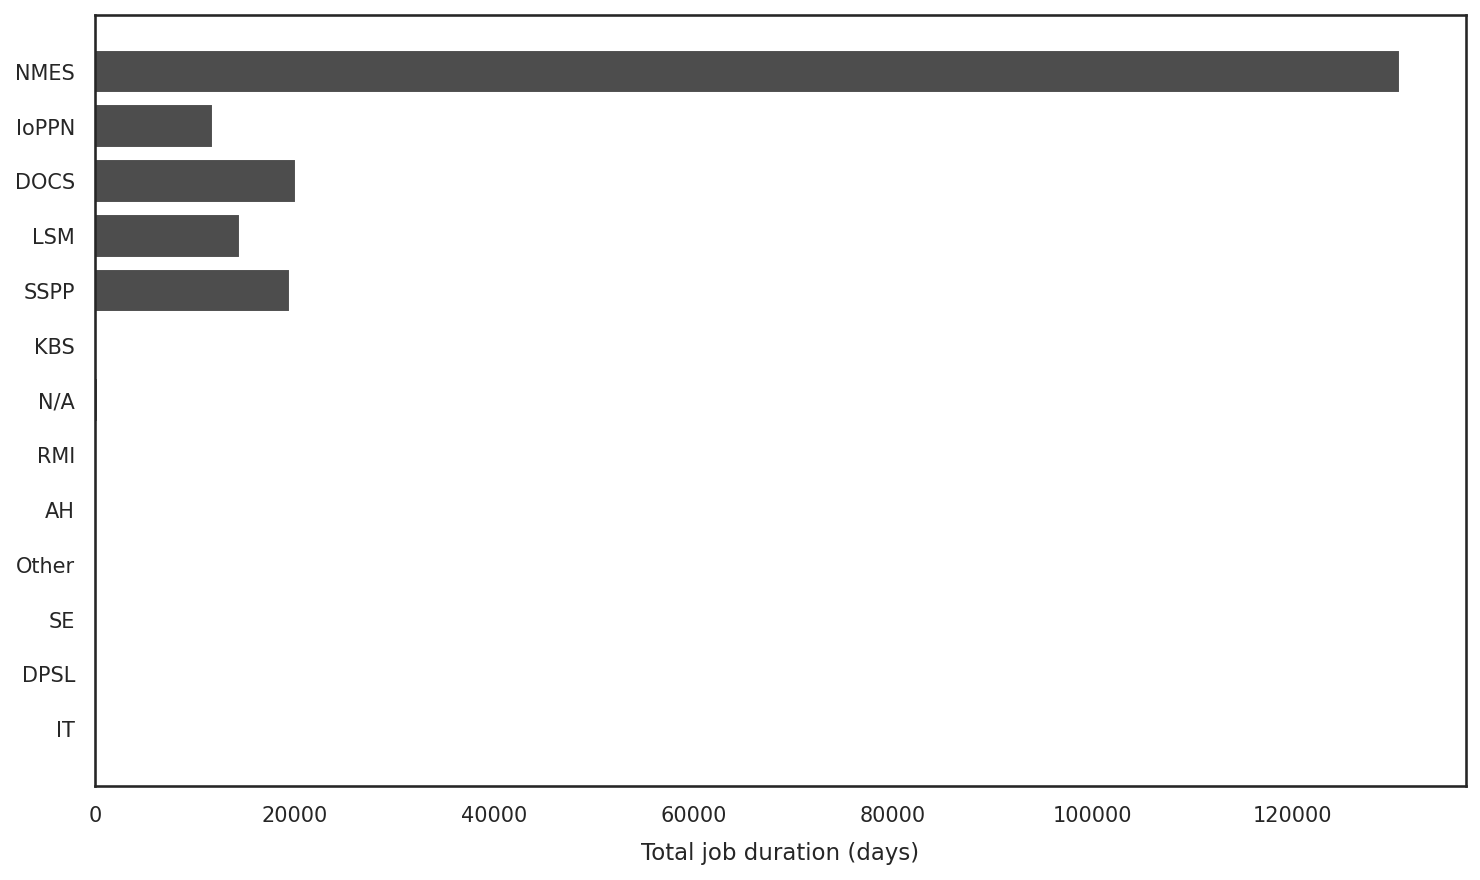

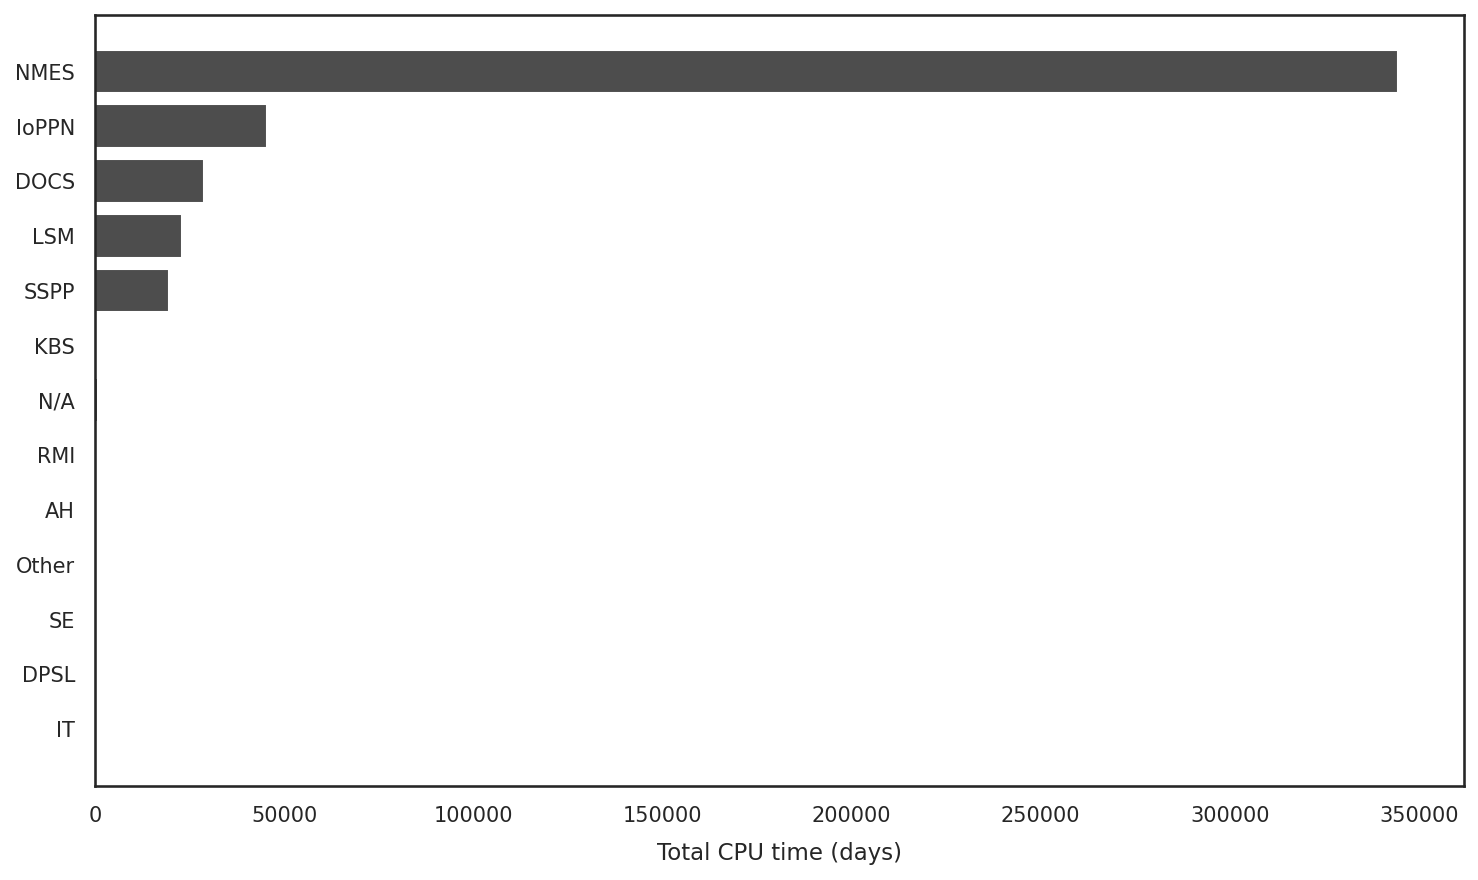

In [4]:
BAR_COLOR = '#4d4d4d'

def overview_bar(values, labels, xlabel):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(labels, values, color=BAR_COLOR)
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    plt.show()

overview_bar(df_plot['job_count'], df_plot['faculty_short'], 'Total jobs')
overview_bar(df_plot['total_elapsed_sec'] / 86400, df_plot['faculty_short'], 'Total job duration (days)')
overview_bar(df_plot['total_cpu_sec'] / 86400, df_plot['faculty_short'], 'Total CPU time (days)')

---
# 2. Global Stats

Key cluster-wide metrics using **weighted efficiency** (total used / total allocated).

In [5]:
def create_summary():
    total_jobs = df_faculties['job_count'].sum()
    total_success = df_faculties['job_count_success'].sum()
    success_rate = (total_success / total_jobs * 100) if total_jobs > 0 else 0
    
    if len(df_global) > 0:
        global_cpu_eff = df_global['weighted_cpu_eff_req'].values[0]
        global_mem_eff = df_global['weighted_mem_eff'].values[0]
    else:
        global_cpu_eff = df_faculties['weighted_cpu_eff_req'].mean()
        global_mem_eff = df_faculties['weighted_mem_eff'].mean()
    
    if HAS_JOB_DATA and 'wait_sec' in df_jobs.columns:
        median_wait = df_jobs['wait_sec'].median() / 60
    else:
        median_wait = df_faculties['avg_wait_sec'].median() / 60
    
    summary = f"""
## Cluster-Wide Summary (Weighted Efficiency)

| Metric | Value |
|--------|-------|
| **Total Jobs** | {total_jobs:,} |
| **Success Rate** | {success_rate:.1f}% |
| **CPU Efficiency** (weighted) | {global_cpu_eff:.1f}% |
| **Memory Efficiency** (weighted) | {global_mem_eff:.1f}% |
| **Median Queue Wait** | {median_wait:.1f} min |

*Weighted efficiency = total resources used / total resources allocated. Larger jobs contribute more.*
"""
    display(Markdown(summary))

create_summary()


## Cluster-Wide Summary (Weighted Efficiency)

| Metric | Value |
|--------|-------|
| **Total Jobs** | 3,717,485 |
| **Success Rate** | 76.3% |
| **CPU Efficiency** (weighted) | 52.2% |
| **Memory Efficiency** (weighted) | 2.4% |
| **Median Queue Wait** | 5.0 min |

*Weighted efficiency = total resources used / total resources allocated. Larger jobs contribute more.*


In [6]:
def efficiency_ranking():
    ranking = df_faculties[['faculty', 'job_count', 'weighted_cpu_eff_req', 'weighted_mem_eff', 'job_count_failed']].copy()
    ranking['failure_rate'] = (ranking['job_count_failed'] / ranking['job_count'] * 100).round(1)
    ranking = ranking.sort_values('weighted_cpu_eff_req', ascending=False)
    
    display(Markdown("### Faculty Ranking by Weighted CPU Efficiency"))
    display(Markdown("*Weighted efficiency shows overall resource utilisation — faculties with large, inefficient jobs rank lower.*"))
    display(ranking[['faculty', 'job_count', 'weighted_cpu_eff_req', 'weighted_mem_eff', 'failure_rate']].rename(columns={
        'faculty': 'Faculty', 'job_count': 'Jobs', 'weighted_cpu_eff_req': 'CPU Eff %',
        'weighted_mem_eff': 'Mem Eff %', 'failure_rate': 'Failure %'
    }))

efficiency_ranking()

### Faculty Ranking by Weighted CPU Efficiency

*Weighted efficiency shows overall resource utilisation — faculties with large, inefficient jobs rank lower.*

,Faculty,Jobs,CPU Eff %,Mem Eff %,Failure %
8,Other,298,96.800000,11.415547,37.6
4,Faculty of Social Science & Public Policy,82523,95.535478,19.599430,31.9
3,"Faculty of Natural, Mathematical & Engineering...",1455312,61.540000,27.112021,16.4
11,The Dickson Poon School of Law,96,44.990000,797.460746,47.9
1,"Faculty of Dentistry, Oral & Craniofacial Scie...",524149,41.703518,96.661146,8.1
5,IT,45,34.410000,57.118414,66.7
0,Faculty of Arts & Humanities,581,34.010000,383.529994,37.7
6,"Institute of Psychiatry, Psychology & Neurosci...",1095733,33.822332,29.704223,6.4
2,Faculty of Life Sciences & Medicine,475915,25.321650,13.248632,26.1
12,unknown,40741,22.210000,19.057047,58.0


**Column definitions:**
- **Jobs**: Total number of jobs submitted by the faculty
- **CPU Eff %**: Weighted CPU efficiency (total CPU time used / total CPU time allocated × 100)
- **Mem Eff %**: Weighted memory efficiency (total memory used / total memory requested × 100)
- **Failure %**: Percentage of all submitted jobs that failed (FAILED, TIMEOUT, NODE_FAIL, PREEMPTED, OUT_OF_MEMORY). CANCELLED jobs are excluded from failure count since cancellation is intentional. Success = COMPLETED only.

**Observations:**

- **Faculty of Social Science & Public Policy**: Excellent CPU efficiency (97%) while submitting a substantial number of jobs (~22k). A model for efficient cluster usage.

- **Faculty of Natural, Mathematical & Engineering Sciences**: Room for improvement at 53% CPU efficiency. They submit the most jobs by far (~89k), which is why they produce the most absolute CPU waste despite not having the worst efficiency rate.

- **Faculty of Arts & Humanities**: High CPU efficiency (84%), but nearly half their jobs failed (43% failure rate), and the sample size is very small (28 jobs). Not statistically representative.

---
# 3. Detailed Analysis

## 3.1 Resource Waste

From an infrastructure perspective, the key question is: **How much cluster capacity is being wasted?**

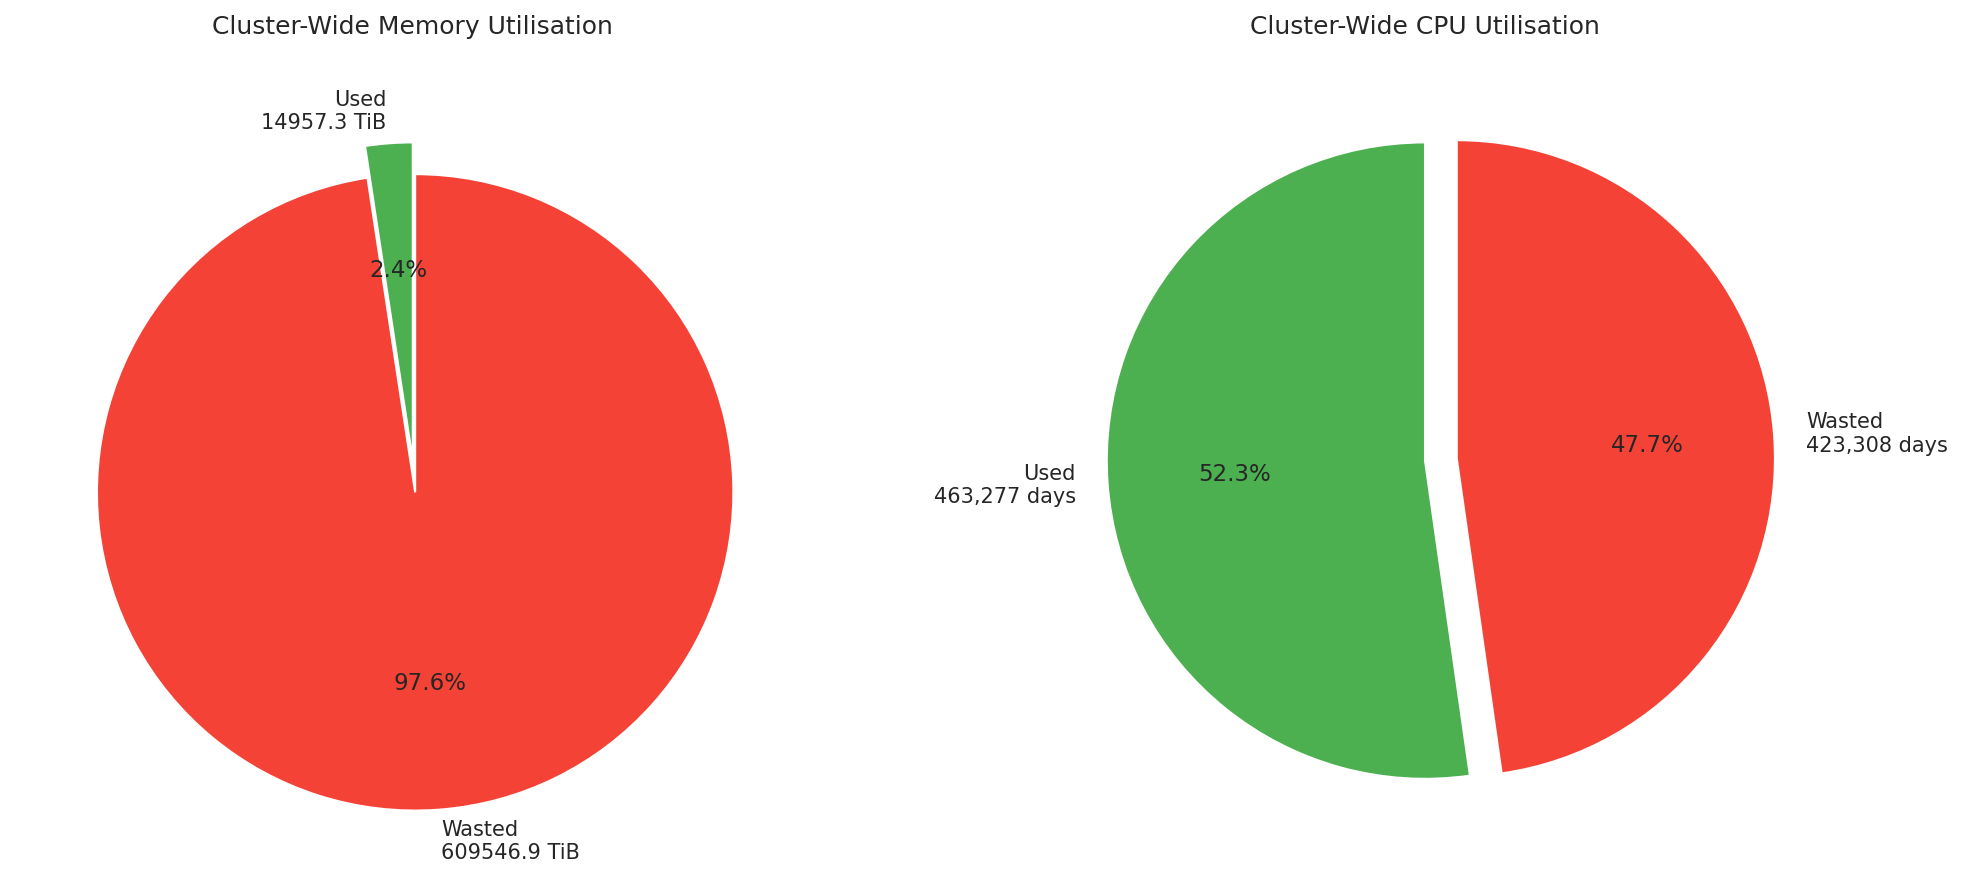

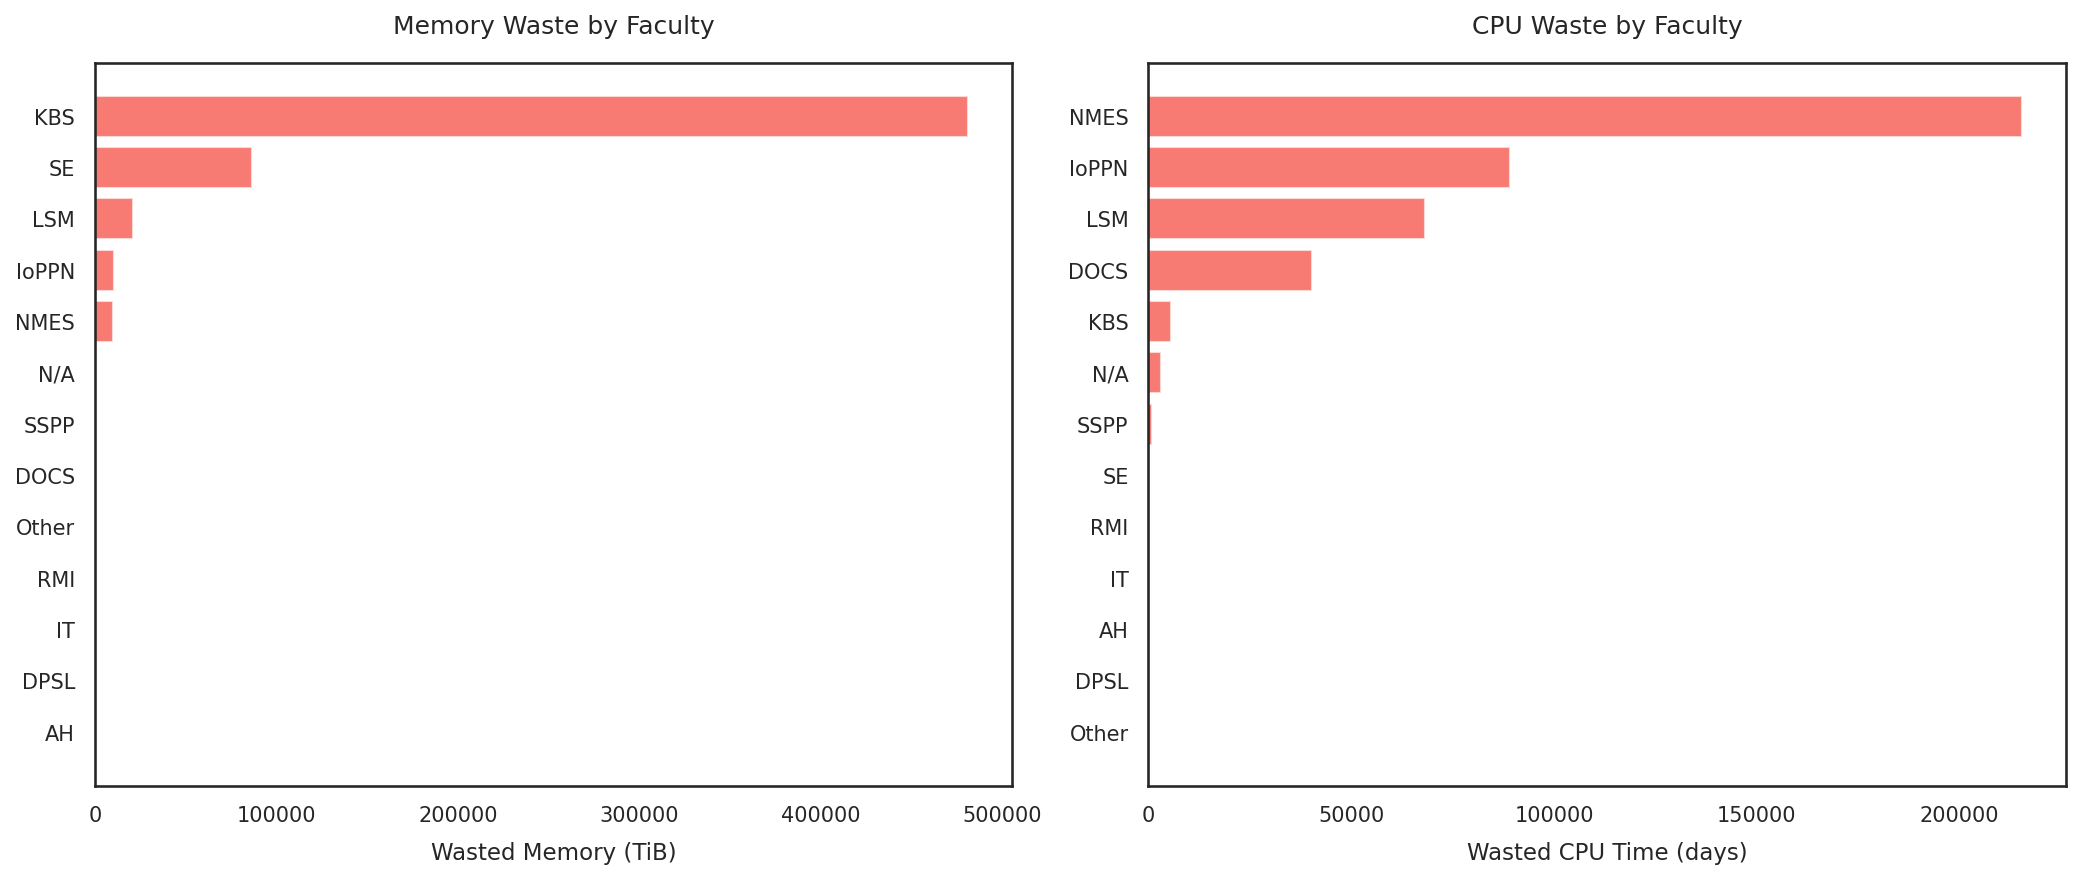

In [7]:
def plot_waste_and_utilisation():
    """Cluster-wide utilisation pies and per-faculty waste bar charts."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Memory utilisation (TiB)
    total_mem_requested = df_faculties['total_reqmem_bytes'].sum() / (1024**4)
    total_mem_used = df_faculties['total_maxrss_bytes'].sum() / (1024**4)
    total_mem_wasted = max(0, total_mem_requested - total_mem_used)

    axes[0].pie([total_mem_used, total_mem_wasted],
                labels=[f'Used\n{total_mem_used:.1f} TiB', f'Wasted\n{total_mem_wasted:.1f} TiB'],
                colors=['#4caf50', '#f44336'], autopct='%1.1f%%',
                startangle=90, explode=(0, 0.1))
    axes[0].set_title('Cluster-Wide Memory Utilisation')

    # CPU utilisation
    cpu_allocated = np.where(
        df_faculties['weighted_cpu_eff_req'] > 0,
        df_faculties['total_cpu_sec'] * 100 / df_faculties['weighted_cpu_eff_req'], 0)
    total_cpu_used = df_faculties['total_cpu_sec'].sum() / 86400
    total_cpu_allocated = cpu_allocated.sum() / 86400
    total_cpu_wasted = max(0, total_cpu_allocated - total_cpu_used)

    axes[1].pie([total_cpu_used, total_cpu_wasted],
                labels=[f'Used\n{total_cpu_used:,.0f} days', f'Wasted\n{total_cpu_wasted:,.0f} days'],
                colors=['#4caf50', '#f44336'], autopct='%1.1f%%',
                startangle=90, explode=(0, 0.1))
    axes[1].set_title('Cluster-Wide CPU Utilisation')

    plt.tight_layout()
    plt.show()

    # Per-faculty waste
    df_faculties['mem_wasted_tib'] = ((df_faculties['total_reqmem_bytes'] -
                                       df_faculties['total_maxrss_bytes']) / (1024**4)).clip(lower=0)
    df_faculties['cpu_wasted_days'] = ((cpu_allocated - df_faculties['total_cpu_sec']) / 86400).clip(lower=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    sorted_df = df_faculties.sort_values('mem_wasted_tib', ascending=True)
    axes[0].barh(sorted_df['faculty_short'], sorted_df['mem_wasted_tib'], color='#f44336', alpha=0.7)
    axes[0].set_xlabel('Wasted Memory (TiB)')
    axes[0].set_title('Memory Waste by Faculty')

    sorted_df = df_faculties.sort_values('cpu_wasted_days', ascending=True)
    axes[1].barh(sorted_df['faculty_short'], sorted_df['cpu_wasted_days'], color='#f44336', alpha=0.7)
    axes[1].set_xlabel('Wasted CPU Time (days)')
    axes[1].set_title('CPU Waste by Faculty')

    plt.tight_layout()
    plt.show()

plot_waste_and_utilisation()

## 3.2 Efficiency by Faculty

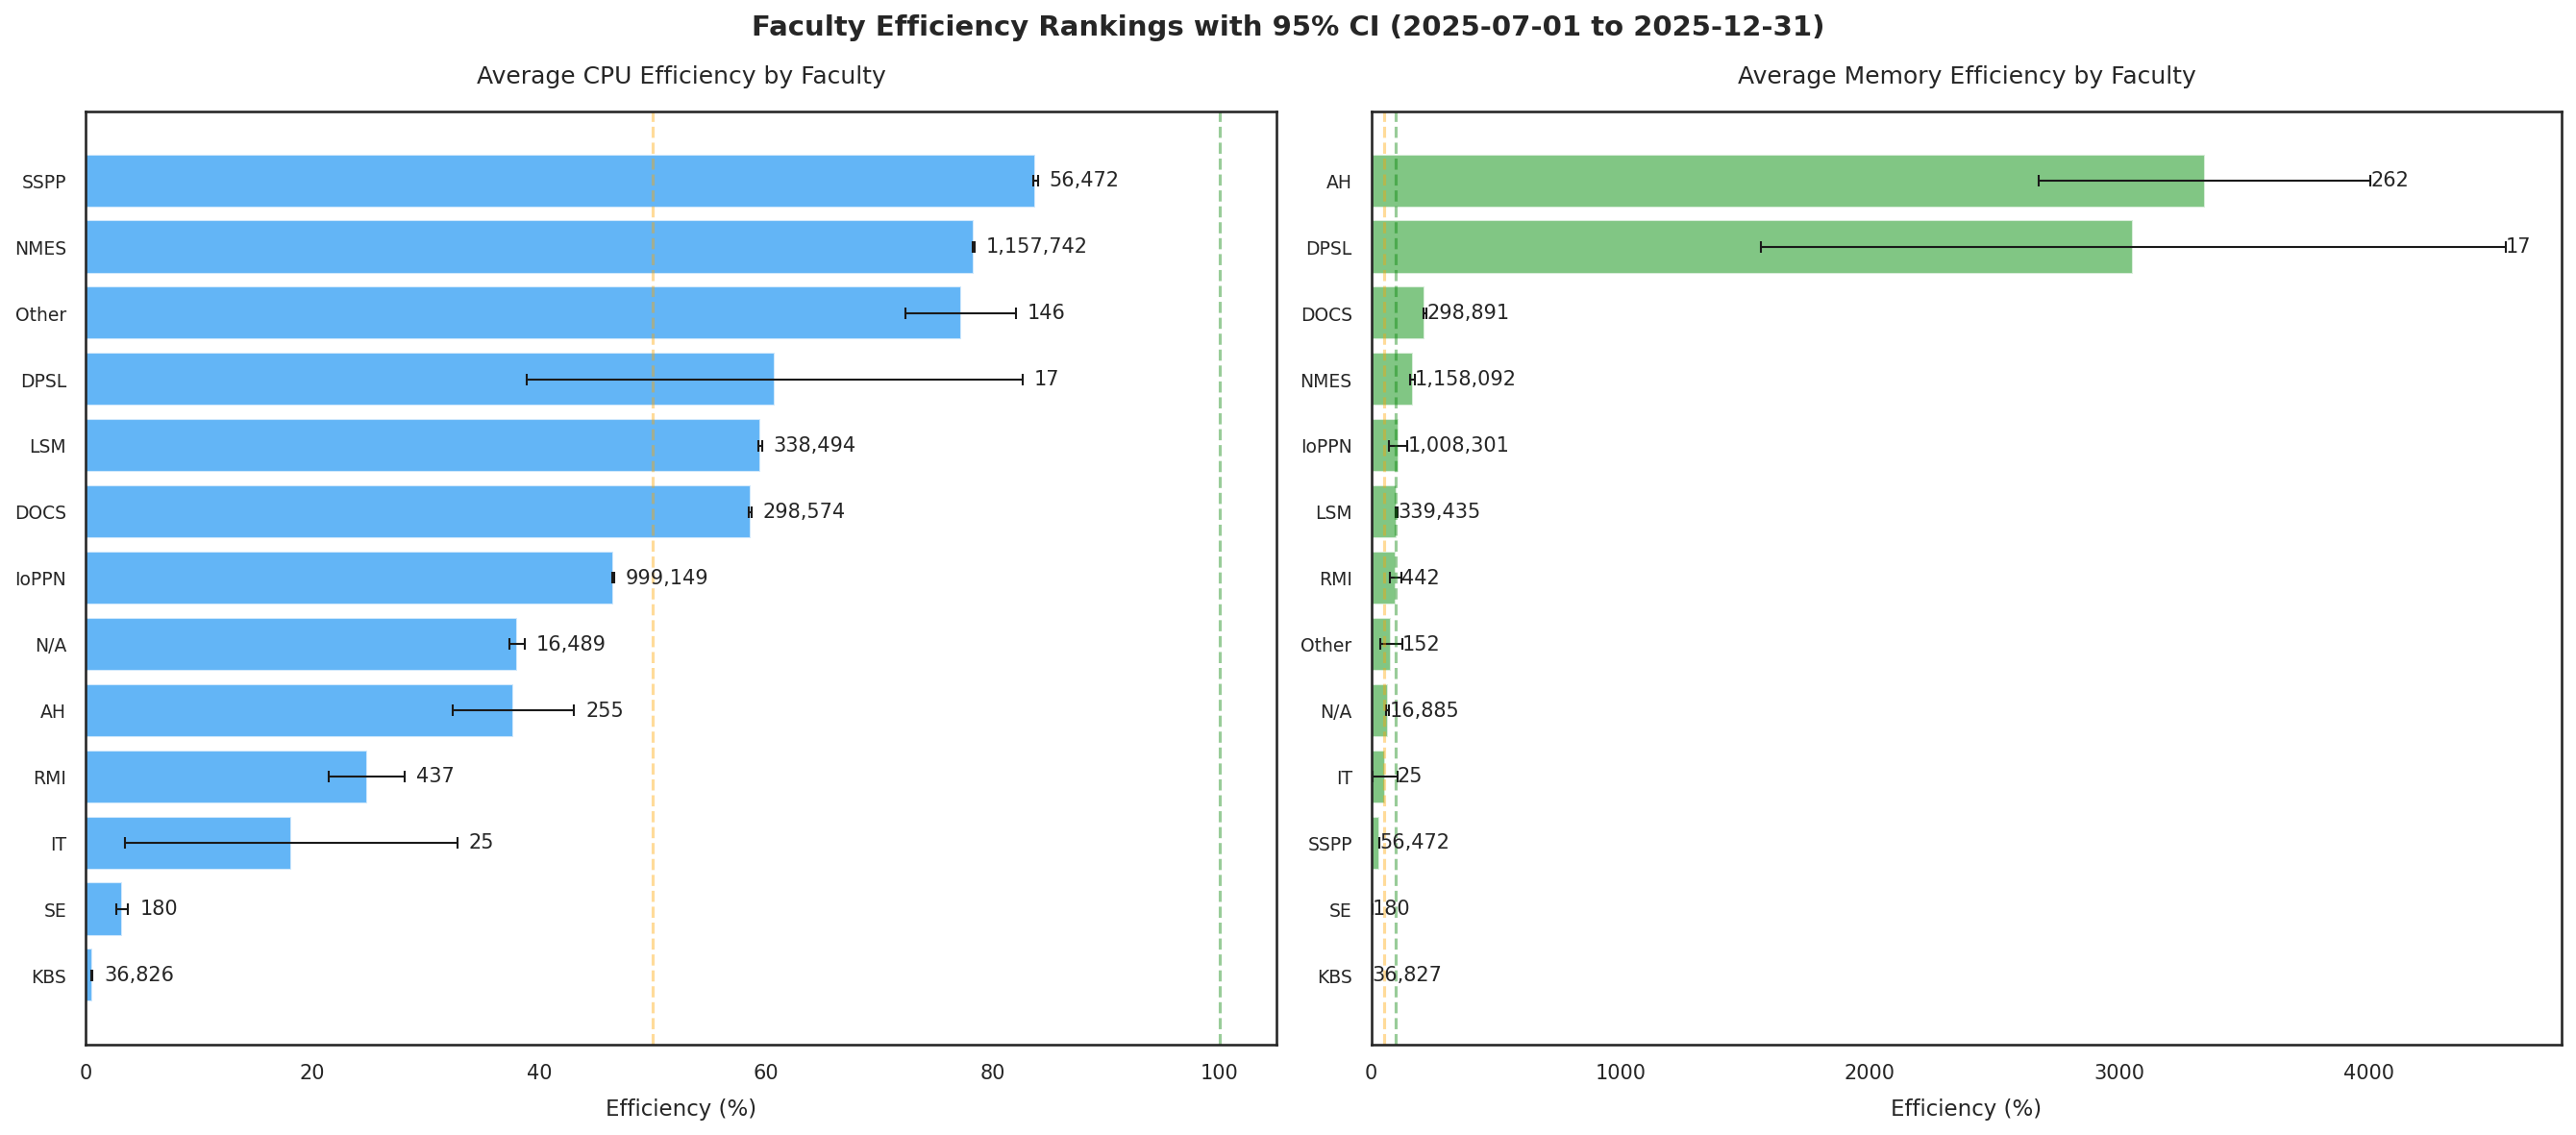


*Numbers at the tip of each bar indicate the number of jobs included.
Error bars show 95% confidence intervals around the mean.*

*Note: This plot shows **average** (per-job mean) efficiency with CIs for
statistical comparability. For **weighted** efficiency (where larger jobs
contribute more), see the ranking table above.*


In [8]:
def faculty_ci_stats(col):
    """Compute per-faculty mean and 95% CI from job-level data."""
    if not HAS_JOB_DATA or 'faculty' not in df_jobs.columns:
        return pd.DataFrame()
    rows = []
    for fac in df_jobs['faculty'].unique():
        vals = df_jobs.loc[df_jobs['faculty'] == fac, col].dropna()
        if len(vals) < 5:
            continue
        mean = vals.mean()
        se = vals.std() / np.sqrt(len(vals))
        ci = 1.96 * se
        rows.append({
            'faculty': fac,
            'faculty_short': FACULTY_SHORT.get(fac, fac),
            'mean': mean,
            'ci': ci,
            'n': len(vals),
        })
    return pd.DataFrame(rows).sort_values('mean', ascending=True)

def plot_efficiency():
    if not HAS_JOB_DATA or 'faculty' not in df_jobs.columns:
        # Fallback to aggregate data without CIs
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        sorted_df = df_faculties.sort_values('weighted_cpu_eff_req', ascending=True)
        axes[0].barh(sorted_df['faculty_short'], sorted_df['weighted_cpu_eff_req'], color='#2196f3')
        axes[0].set_xlabel('Efficiency (%)')
        axes[0].set_title('Weighted CPU Efficiency by Faculty')
        axes[0].axvline(x=100, color='green', linestyle='--', alpha=0.5)
        axes[0].axvline(x=50, color='orange', linestyle='--', alpha=0.5)
        sorted_df = df_faculties.sort_values('weighted_mem_eff', ascending=True)
        axes[1].barh(sorted_df['faculty_short'], sorted_df['weighted_mem_eff'], color='#4caf50')
        axes[1].set_xlabel('Efficiency (%)')
        axes[1].set_title('Weighted Memory Efficiency by Faculty')
        axes[1].axvline(x=100, color='green', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
        return

    cpu_fstats = faculty_ci_stats('cpu_eff_req')
    mem_fstats = faculty_ci_stats('mem_eff')

    fig, axes = plt.subplots(1, 2, figsize=(18, max(8, len(cpu_fstats) * 0.6)))

    for ax, fstats, color, title in [
        (axes[0], cpu_fstats, '#2196f3', 'Average CPU Efficiency by Faculty'),
        (axes[1], mem_fstats, '#4caf50', 'Average Memory Efficiency by Faculty'),
    ]:
        y = range(len(fstats))
        ax.barh(y, fstats['mean'], xerr=fstats['ci'],
                color=color, alpha=0.7, edgecolor='white',
                capsize=3, error_kw={'lw': 1})
        ax.set_yticks(list(y))
        ax.set_yticklabels(fstats['faculty_short'], fontsize=9)
        ax.set_xlabel('Efficiency (%)')
        ax.set_title(title)
        ax.axvline(50, color='orange', ls='--', alpha=0.4)
        ax.axvline(100, color='green', ls='--', alpha=0.4)

        for i, (_, row) in enumerate(fstats.iterrows()):
            ax.text(row['mean'] + row['ci'] + 1, i,
                    f'{row["n"]:,}', va='center', fontsize=10)

    plt.suptitle(f'Faculty Efficiency Rankings with 95% CI ({DATE_RANGE})',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    display(Markdown('''
*Numbers at the tip of each bar indicate the number of jobs included.
Error bars show 95% confidence intervals around the mean.*

*Note: This plot shows **average** (per-job mean) efficiency with CIs for
statistical comparability. For **weighted** efficiency (where larger jobs
contribute more), see the ranking table above.*
'''))

plot_efficiency()

## 3.3 Job Success/Failure by Faculty

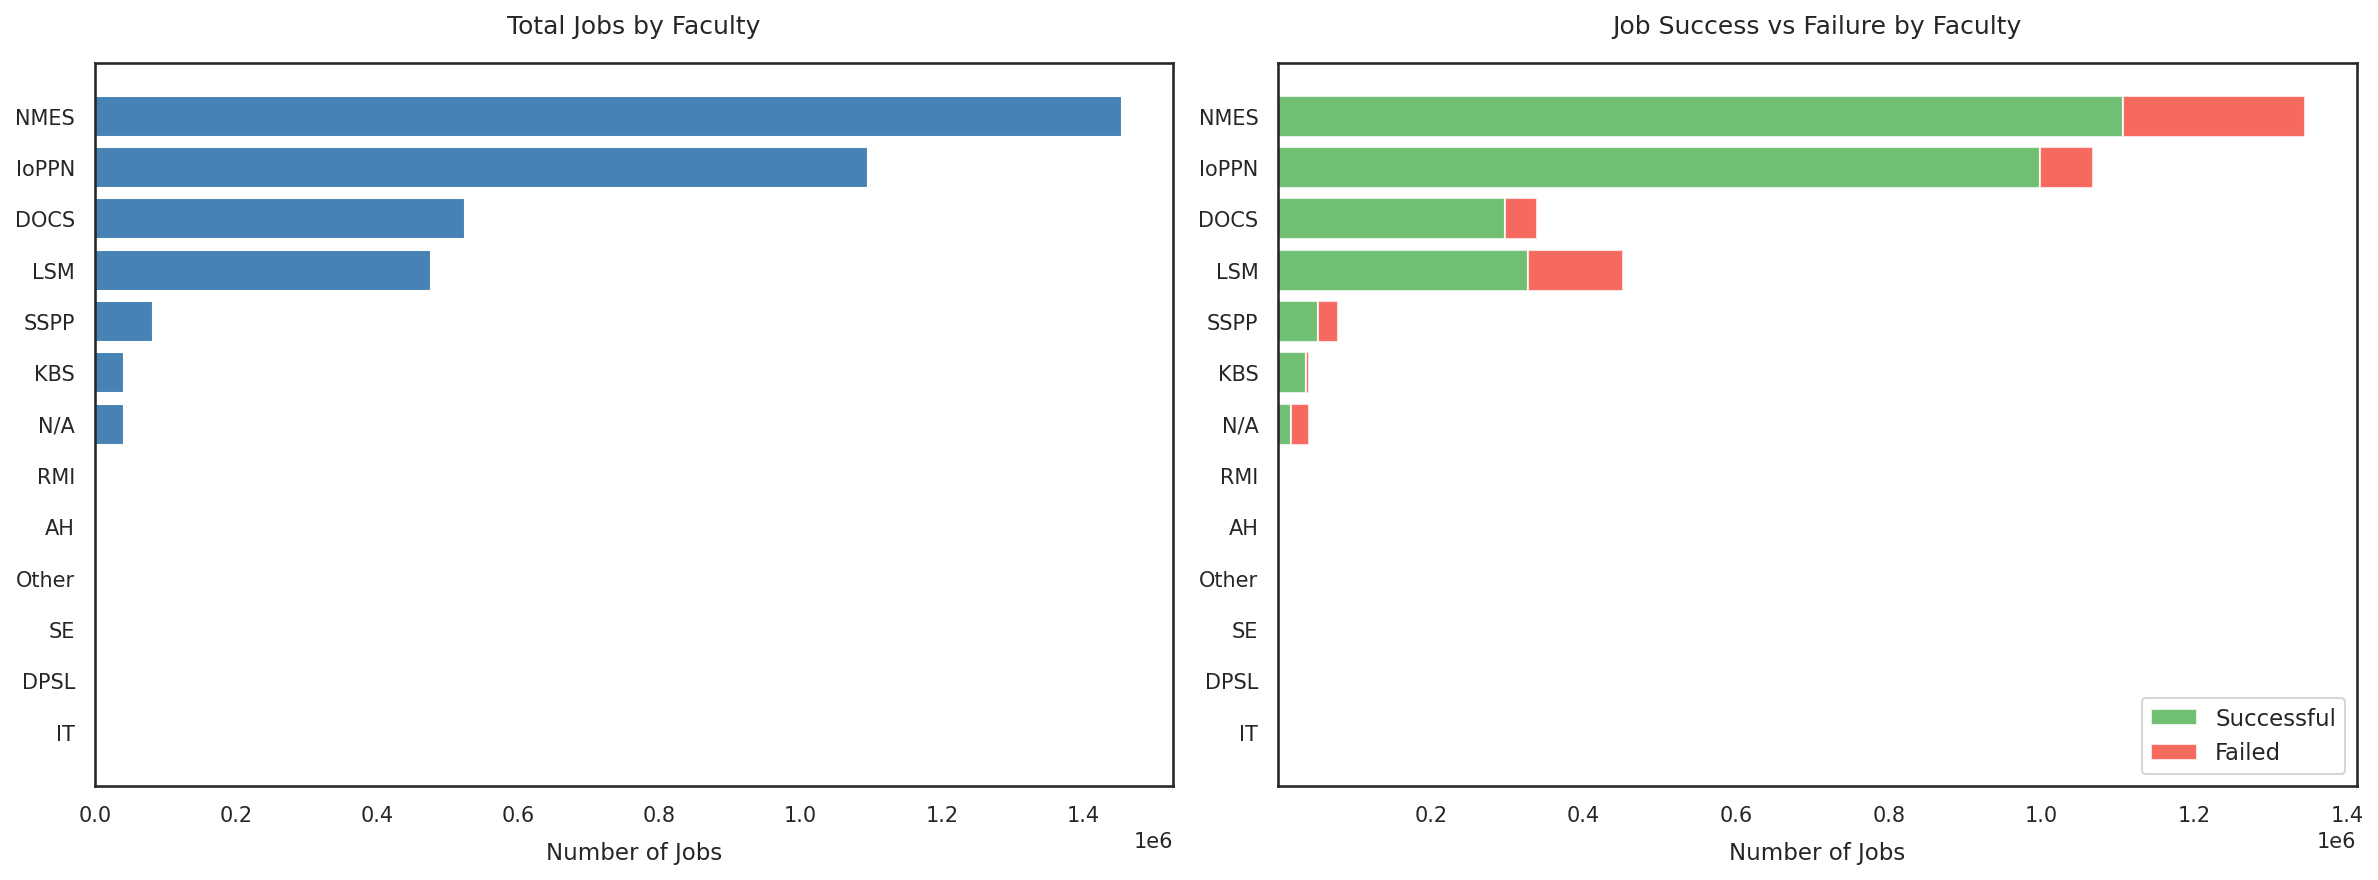

In [9]:
def plot_job_counts():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sorted_df = df_faculties.sort_values('job_count', ascending=True)
    
    axes[0].barh(sorted_df['faculty_short'], sorted_df['job_count'], color='steelblue')
    axes[0].set_xlabel('Number of Jobs')
    axes[0].set_title('Total Jobs by Faculty')
    
    axes[1].barh(sorted_df['faculty_short'], sorted_df['job_count_success'], 
                 label='Successful', color='#4caf50', alpha=0.8)
    axes[1].barh(sorted_df['faculty_short'], sorted_df['job_count_failed'], 
                 left=sorted_df['job_count_success'], label='Failed', color='#f44336', alpha=0.8)
    axes[1].set_xlabel('Number of Jobs')
    axes[1].set_title('Job Success vs Failure by Faculty')
    axes[1].legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()

plot_job_counts()

## 3.4 Nodes per Job

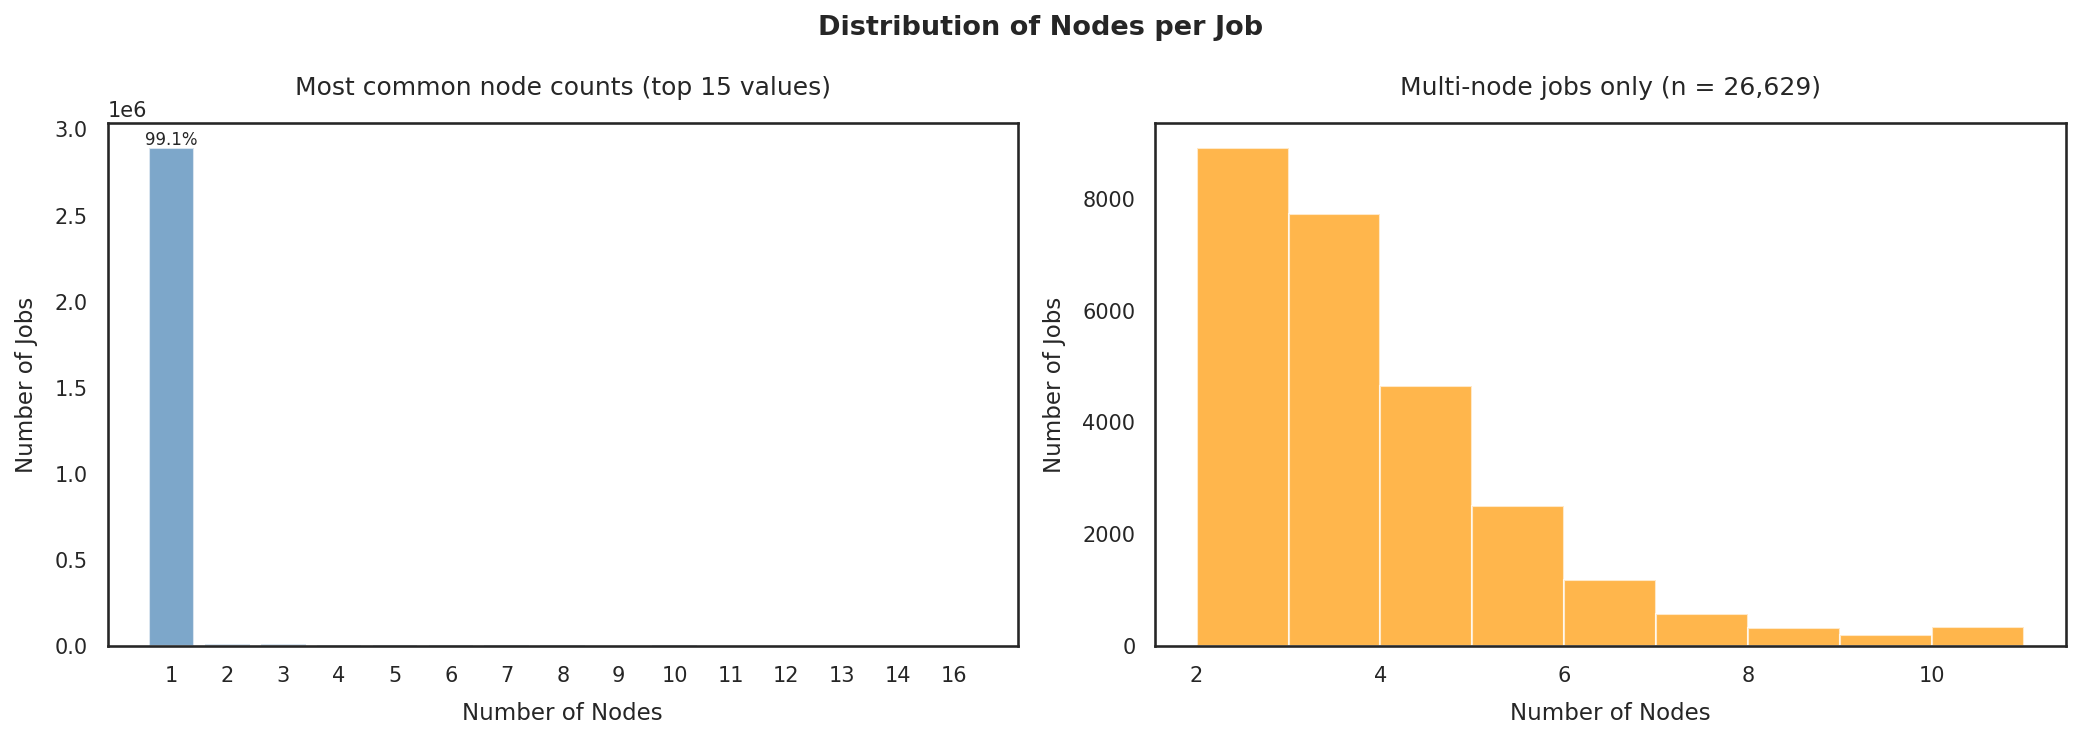


**Summary:** Of **2,915,981** jobs, **2,889,352** (99.1%) used a single node
and **26,629** (0.9%) used multiple nodes.

| Stat | Value |
|------|-------|
| Median | 1 |
| Mean | 1.02 |
| Max | 20 |
| % single-node | 99.1% |


In [10]:
def plot_nodes_distribution():
    """Distribution of nodes requested per job."""
    if not HAS_JOB_DATA:
        print("Per-job data not available.")
        return

    nodes = pd.to_numeric(df_jobs['n_nodes'], errors='coerce').dropna()
    nodes = nodes[nodes > 0]

    n_single = (nodes == 1).sum()
    n_multi = (nodes > 1).sum()
    pct_single = n_single / len(nodes) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: bar chart of most common node counts
    top_vals = nodes.value_counts().head(15).sort_index()
    axes[0].bar(top_vals.index.astype(int).astype(str), top_vals.values,
                color='steelblue', alpha=0.7, edgecolor='white')
    axes[0].set_xlabel('Number of Nodes')
    axes[0].set_ylabel('Number of Jobs')
    axes[0].set_title(f'Most common node counts (top 15 values)')
    for i, (val, count) in enumerate(top_vals.items()):
        pct = count / len(nodes) * 100
        if pct >= 1:
            axes[0].text(i, count, f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

    # Right: multi-node jobs only (zoomed)
    multi = nodes[nodes > 1]
    if len(multi) > 0:
        top_multi = int(multi.quantile(0.99)) if len(multi) > 10 else int(multi.max())
        axes[1].hist(multi[multi <= top_multi], bins=range(2, top_multi + 2),
                     color='#ff9800', alpha=0.7, edgecolor='white')
        axes[1].set_xlabel('Number of Nodes')
        axes[1].set_ylabel('Number of Jobs')
        axes[1].set_title(f'Multi-node jobs only (n = {n_multi:,})')
    else:
        axes[1].text(0.5, 0.5, 'No multi-node jobs', transform=axes[1].transAxes,
                     ha='center', fontsize=14)

    plt.suptitle('Distribution of Nodes per Job', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    display(Markdown(f'''
**Summary:** Of **{len(nodes):,}** jobs, **{n_single:,}** ({pct_single:.1f}%) used a single node
and **{n_multi:,}** ({100 - pct_single:.1f}%) used multiple nodes.

| Stat | Value |
|------|-------|
| Median | {nodes.median():.0f} |
| Mean | {nodes.mean():.2f} |
| Max | {nodes.max():.0f} |
| % single-node | {pct_single:.1f}% |
'''))

plot_nodes_distribution()

---
# 4. Correlation Analysis

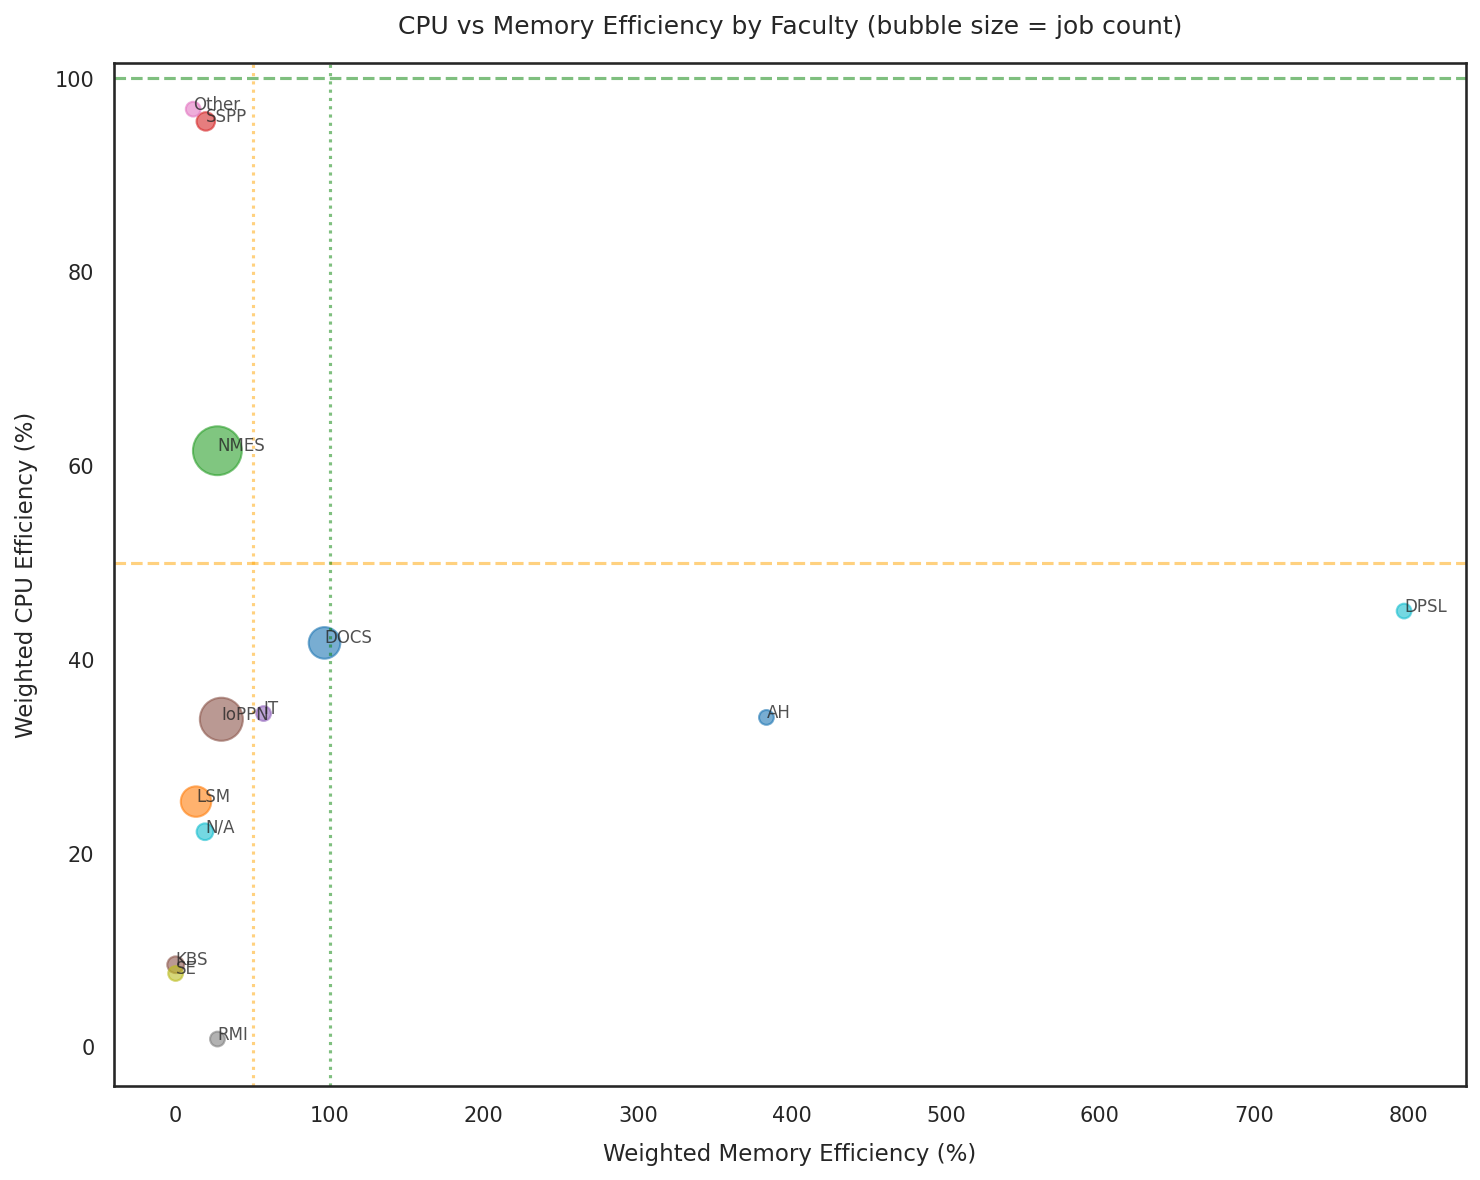

In [11]:
def cpu_memory_scatter():
    """Scatter plot: CPU vs Memory efficiency by faculty."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    plot_df = df_faculties.dropna(subset=['weighted_cpu_eff_req', 'weighted_mem_eff'])
    
    ax.scatter(plot_df['weighted_mem_eff'], plot_df['weighted_cpu_eff_req'],
               s=plot_df['job_count']/plot_df['job_count'].max()*500+50,
               alpha=0.6, c=range(len(plot_df)), cmap='tab10')
    
    for idx, row in plot_df.iterrows():
        ax.annotate(row['faculty_short'].replace('\n', ' '),
                    (row['weighted_mem_eff'], row['weighted_cpu_eff_req']),
                   fontsize=8, alpha=0.8)
    
    ax.axhline(y=50, color='orange', linestyle='--', alpha=0.5)
    ax.axhline(y=100, color='green', linestyle='--', alpha=0.5)
    ax.axvline(x=50, color='orange', linestyle=':', alpha=0.5)
    ax.axvline(x=100, color='green', linestyle=':', alpha=0.5)
    
    ax.set_xlabel('Weighted Memory Efficiency (%)')
    ax.set_ylabel('Weighted CPU Efficiency (%)')
    ax.set_title('CPU vs Memory Efficiency by Faculty (bubble size = job count)')
    plt.tight_layout()
    plt.show()

cpu_memory_scatter()

---
# 5. Technical Appendix

## Data Sources

- **Job data:** Slurm accounting database (MySQL), accessed directly via `mysql.connector` (not via `sacct`, for reliability).
  - `create_job_table`: job metadata — timestamps, resource requests (`cpus_req`, `tres_req`), state, time limit
  - `create_step_table`: per-step CPU time (`user_sec`, `sys_sec`) and peak memory usage (`tres_usage_in_max`)
  - `create_assoc_table`: maps job associations to usernames
- **Faculty mapping:** Active Directory via LDAP. Each username is looked up to retrieve its faculty attribute (`st`).

## Efficiency Metrics

### Weighted vs Average

This notebook uses **weighted efficiency** — total resources used divided by total resources allocated. Larger jobs contribute more because they consume more cluster capacity.

| Version | Formula | Question it answers |
|---------|---------|---------------------|
| **Weighted** | Sum(used) / Sum(allocated) × 100 | "How efficiently are allocated resources being used overall?" Larger jobs contribute more. |
| **Average** | Mean(per-job efficiency) | "What's the typical job's efficiency?" Each job counts equally. |

For user-focused analysis (where each job counts equally), see `visualisation_users.ipynb`.

### CPU Efficiency

`CPU Efficiency = TotalCPU / (Elapsed × CPUs) × 100`

- **TotalCPU** = user-mode CPU seconds + system-mode CPU seconds + microsecond fractions.
- **CPUs** = either `cpus_req` (requested) or `alloc_cpus` (allocated) from the job table.

**Why efficiency based on requested CPUs can exceed 100%:**
- Code uses more threads than requested (under-requesting)
- Slurm allocates more CPUs than requested due to core-level allocation

**Requested vs allocated CPUs:** The cluster uses `CR_CORE_MEMORY` allocation (`SelectTypeParameters`), meaning Slurm allocates whole cores. On hyperthreaded nodes (2 threads per core), requesting 1 CPU allocates 1 core = 2 hardware threads. The `alloc_cpus` field stores hardware threads, so `alloc_cpus` can be 2× `req_cpus`.

**Why efficiency based on allocated CPUs can still exceed 100%:** With `ConstrainCores` enabled, jobs are restricted to their allocated cores, so efficiency should theoretically be ≤100%. The cause of >100% values is not fully understood — possibly related to multi-node job accounting or other Slurm internals.

### Memory Efficiency

`Memory Efficiency = MaxRSS / ReqMem × 100`

- **MaxRSS**: Peak memory usage across all steps.
- **ReqMem**: Requested memory (always stored as total memory regardless of how it was requested).

**Why it can exceed 100%:** The data in this analysis is from a period when memory limits were **not enforced** (`ConstrainRAMSpace` was disabled). Jobs could exceed requested memory without being killed. Memory enforcement has since been enabled — new jobs exceeding their memory request will be terminated.

### Time Efficiency

`Time Efficiency = Elapsed / (Timelimit × 60) × 100`

Measures what fraction of the requested wall-clock time was actually used.

## Resource Enforcement (cgroups)

Slurm can enforce resource limits using Linux cgroups:

| Resource | Setting | Status | Effect |
|----------|---------|--------|--------|
| Memory | `ConstrainRAMSpace` | Now enabled | Jobs killed if exceeding request |
| CPU | `ConstrainCores` | Enabled | Jobs restricted to allocated cores |

With `ConstrainCores` enabled, jobs are restricted to their allocated cores.

## Job States Included

Only jobs in specific terminal states are included:

| State | Included | Why |
|-------|----------|-----|
| COMPLETED | **Yes** | Clean efficiency data |
| TIMEOUT | **Yes** | Job ran its full requested time |
| OUT_OF_MEMORY | **Yes** | Shows memory under-requesting |
| CANCELLED, FAILED, NODE_FAIL, PREEMPTED | No | Incomplete, potentially misleading |

**Success/Failure Metrics:** Computed across ALL job states:
- Success = COMPLETED only
- Failed = FAILED, TIMEOUT, NODE_FAIL, PREEMPTED, OUT_OF_MEMORY
- CANCELLED is excluded from failure count (intentional user action)

**Efficiency Metrics:** Only computed for COMPLETED, TIMEOUT, and OUT_OF_MEMORY jobs (which ran long enough to have meaningful resource usage data).

## CPU Time and Step Handling

Slurm records CPU time per step within each job. For jobs using `srun`, the batch step records only shell overhead, while the srun steps carry the actual computation. The SQL query sums only regular steps, falling back to the batch step for jobs that have no `srun` steps.

## Faculty Merging

Four pairs of historically different names for the same faculty are merged before analysis:

| Old name | Merged into |
|----------|-------------|
| Faculty of Life Sciences and Medicine | Faculty of Life Sciences & Medicine |
| IoPPN | Institute of Psychiatry, Psychology & Neuroscience |
| Dentistry, Oral & Craniofacial Sciences | Faculty of Dentistry, Oral & Craniofacial Sciences |
| Social Science & Public Policy | Faculty of Social Science & Public Policy |

In [12]:
display(Markdown("### Raw Faculty Data"))
display(df_faculties)

### Raw Faculty Data

,faculty,job_count,job_count_success,job_count_failed,count_timeout,count_out_of_memory,total_elapsed_sec,total_cpu_sec,total_user_cpu_sec,total_sys_cpu_sec,...,weighted_cpu_eff_alloc,weighted_mem_eff,weighted_time_eff,avg_cpu_eff_req,avg_cpu_eff_alloc,avg_mem_eff,avg_time_eff,faculty_short,mem_wasted_tib,cpu_wasted_days
0,Faculty of Arts & Humanities,581,228,219,34,0,1.561950e+06,1.513209e+06,1.473781e+06,3.942869e+04,...,29.920000,383.529994,12.510000,37.730000,23.780000,3342.920000,28.060000,AH,0.000000,33.982612
1,"Faculty of Dentistry, Oral & Craniofacial Scie...",524149,296721,42283,2311,0,1.745397e+09,2.500736e+09,2.245187e+09,2.555494e+08,...,39.299466,96.661146,10.382499,63.391350,57.288908,246.115605,9.316611,DOCS,121.775654,40459.806631
2,Faculty of Life Sciences & Medicine,475915,327845,123984,11655,0,1.253543e+09,1.998303e+09,1.811071e+09,1.872319e+08,...,19.694339,13.248632,NaN,58.739043,53.909323,101.968824,9.603983,LSM,20902.268701,68210.363235
3,"Faculty of Natural, Mathematical & Engineering...",1455312,1106368,239207,52019,0,1.130480e+10,2.977008e+10,2.892777e+10,8.423072e+08,...,57.610000,27.112021,NaN,78.330000,76.170000,166.190000,23.390000,NMES,9817.820416,215336.698982
4,Faculty of Social Science & Public Policy,82523,52038,26366,4434,0,1.686906e+09,1.689090e+09,1.682088e+09,7.002143e+06,...,95.044743,19.599430,18.651273,83.758302,83.573826,31.561757,18.320539,SSPP,163.228903,913.585528
5,IT,45,3,30,22,0,3.944315e+06,2.765349e+06,1.533785e+06,1.231564e+06,...,23.780000,57.118414,93.170000,18.110000,11.340000,54.650000,93.300000,IT,0.750428,61.008342
6,"Institute of Psychiatry, Psychology & Neurosci...",1095733,998442,69688,9859,0,1.020551e+09,3.939684e+09,3.585451e+09,3.542322e+08,...,33.541820,29.704223,0.020987,46.469643,44.222982,108.419134,7.425892,IoPPN,10276.006898,89218.620680
7,King's Business School,41032,36692,4157,135,0,8.523687e+06,4.559933e+07,4.372911e+07,1.870220e+06,...,8.480000,0.017924,0.230000,0.590000,0.590000,1.160000,0.570000,KBS,481442.216857,5695.932931
8,Other,298,152,112,0,0,1.281890e+05,1.240845e+05,1.092242e+05,1.486025e+04,...,96.800000,11.415547,0.940000,77.180000,77.180000,79.520000,1.400000,Other,19.686663,0.047476
9,Research Management & Innovation,798,364,265,78,0,1.107658e+06,7.156932e+04,6.521690e+04,6.352420e+03,...,0.780000,27.169768,NaN,24.800000,23.600000,98.150000,25.500000,RMI,4.000178,101.436912


## Aggregate Stats Column Reference

| Column | Description |
|--------|-------------|
| `faculty` | Faculty name (from LDAP lookup) |
| `job_count` | Total jobs submitted (all states) |
| `job_count_success` | Jobs that completed successfully (COMPLETED state only) |
| `job_count_failed` | Jobs that failed (FAILED, TIMEOUT, NODE_FAIL, PREEMPTED, OUT_OF_MEMORY) |
| `count_timeout` | Jobs that hit their time limit |
| `count_out_of_memory` | Jobs killed for exceeding memory |
| `total_elapsed_sec` | Sum of wall-clock time across efficiency jobs |
| `avg_elapsed_sec` | Mean wall-clock time per efficiency job |
| `total_cpu_sec` | Sum of CPU time (user + system) across efficiency jobs |
| `avg_cpu_sec` | Mean CPU time per efficiency job |
| `total_user_cpu_sec` | CPU time in user mode (application code) |
| `total_sys_cpu_sec` | CPU time in system mode (kernel/OS operations) |
| `user_cpu_pct` | Percentage of CPU time in user mode |
| `sys_cpu_pct` | Percentage of CPU time in system mode |
| `total_maxrss_bytes` | Sum of peak memory usage |
| `avg_maxrss_bytes` | Mean peak memory usage per job |
| `total_reqmem_bytes` | Sum of requested memory |
| `avg_reqmem_bytes` | Mean requested memory per job |
| `total_reqcpus` | Sum of requested CPUs |
| `avg_reqcpus` | Mean requested CPUs per job |
| `total_nodes` | Sum of nodes used |
| `total_wait_sec` | Sum of queue wait time |
| `avg_wait_sec` | Mean queue wait time per job |
| `weighted_cpu_eff_req` | CPU efficiency based on requested CPUs: total_cpu / (elapsed × req_cpus) |
| `avg_cpu_eff_req` | Mean of per-job CPU efficiency (requested) |
| `weighted_cpu_eff_alloc` | CPU efficiency based on allocated CPUs |
| `avg_cpu_eff_alloc` | Mean of per-job CPU efficiency (allocated) |
| `weighted_mem_eff` | Memory efficiency: total_maxrss / total_reqmem |
| `avg_mem_eff` | Mean of per-job memory efficiency |
| `weighted_time_eff` | Time efficiency: total_elapsed / total_timelimit |
| `avg_time_eff` | Mean of per-job time efficiency |

*Note: Resource totals/averages and efficiency metrics are computed from efficiency jobs only (COMPLETED + TIMEOUT + OUT_OF_MEMORY).*

In [13]:
# Sanity Check: CPU Efficiency - Requested vs Allocated CPUs
display(Markdown("## CPU Efficiency: Requested vs Allocated"))
display(Markdown("""
This compares CPU efficiency calculated using:
- **Requested CPUs** (`req_cpus`): What users asked for
- **Allocated CPUs** (`alloc_cpus`): Hardware threads allocated by Slurm

**Cluster configuration:** `SelectTypeParameters = CR_CORE_MEMORY`
- Slurm allocates whole cores, not individual hardware threads
- On hyperthreaded nodes (2 threads per core), requesting 1 CPU allocates 1 core = 2 hardware threads
- `alloc_cpus` stores hardware threads, so it can be 2× `req_cpus`

**Why >100% in single jobs still appears with allocated CPUs:** With `ConstrainCores` enabled, efficiency should theoretically be ≤100%. The cause of >100% values is not fully understood.
"""))

# Global stats
display(Markdown("### Global Stats"))
global_df = pd.read_csv(FACULTY_STATS_PATH, comment='#')
global_df = global_df[global_df['faculty'].str.strip('"') == 'all']
if len(global_df) > 0:
    global_comparison = pd.DataFrame({
        'Metric': ['Weighted CPU Efficiency'],
        'Based on Requested': [f"{global_df['weighted_cpu_eff_req'].values[0]:.1f}%"],
        'Based on Allocated': [f"{global_df['weighted_cpu_eff_alloc'].values[0]:.1f}%"]
    })
    display(global_comparison)
else:
    print("No global stats found. Run aggregate_stats with --collate_by none to generate.")

# Faculty stats
display(Markdown("### By Faculty"))
cols_to_show = ['faculty', 'job_count', 'weighted_cpu_eff_req', 'weighted_cpu_eff_alloc']
cols_available = [c for c in cols_to_show if c in df_faculties.columns]
if 'weighted_cpu_eff_alloc' in cols_available:
    comparison_df = df_faculties[cols_available].copy()
    comparison_df = comparison_df.sort_values('job_count', ascending=False)
    display(comparison_df.round(1))
else:
    print("Allocated CPU efficiency columns not found in data.")

## CPU Efficiency: Requested vs Allocated


This compares CPU efficiency calculated using:
- **Requested CPUs** (`req_cpus`): What users asked for
- **Allocated CPUs** (`alloc_cpus`): Hardware threads allocated by Slurm

**Cluster configuration:** `SelectTypeParameters = CR_CORE_MEMORY`
- Slurm allocates whole cores, not individual hardware threads
- On hyperthreaded nodes (2 threads per core), requesting 1 CPU allocates 1 core = 2 hardware threads
- `alloc_cpus` stores hardware threads, so it can be 2× `req_cpus`

**Why >100% in single jobs still appears with allocated CPUs:** With `ConstrainCores` enabled, efficiency should theoretically be ≤100%. The cause of >100% values is not fully understood.


### Global Stats

,Metric,Based on Requested,Based on Allocated
0,Weighted CPU Efficiency,52.2%,48.4%


### By Faculty

,faculty,job_count,weighted_cpu_eff_req,weighted_cpu_eff_alloc
3,"Faculty of Natural, Mathematical & Engineering...",1455312,61.5,57.6
6,"Institute of Psychiatry, Psychology & Neurosci...",1095733,33.8,33.5
1,"Faculty of Dentistry, Oral & Craniofacial Scie...",524149,41.7,39.3
2,Faculty of Life Sciences & Medicine,475915,25.3,19.7
4,Faculty of Social Science & Public Policy,82523,95.5,95.0
7,King's Business School,41032,8.5,8.5
12,unknown,40741,22.2,20.7
9,Research Management & Innovation,798,0.8,0.8
0,Faculty of Arts & Humanities,581,34.0,29.9
8,Other,298,96.8,96.8


In [14]:
# Memory Efficiency: Requested vs Allocated
display(Markdown("## Memory Efficiency: Requested vs Allocated"))
display(Markdown("""
This compares memory efficiency calculated using:
- **Requested memory** (`tres_req`): total memory the user requested
- **Allocated memory** (`tres_alloc`): total memory Slurm actually reserved

For `--mem-per-cpu` jobs, when `alloc_cpus > cpus_req` (due to core-level allocation on hyperthreaded nodes), Slurm allocates proportionally more memory than requested. With `ConstrainRAMSpace` enabled, the cgroup enforces the **allocated** amount, so jobs can legally use more memory than they requested.
"""))

# Global stats
display(Markdown("### Global Stats"))
global_df = pd.read_csv(FACULTY_STATS_PATH, comment='#')
global_df['faculty'] = global_df['faculty'].str.strip('"')
global_df_all = global_df[global_df['faculty'] == 'all']
if len(global_df_all) > 0 and 'weighted_mem_eff_alloc' in global_df_all.columns:
    global_df_all = global_df_all.replace('NULL', np.nan)
    for col in ['weighted_mem_eff', 'weighted_mem_eff_alloc']:
        if col in global_df_all.columns:
            global_df_all[col] = pd.to_numeric(global_df_all[col], errors='coerce')
    global_comparison = pd.DataFrame({
        'Metric': ['Weighted Memory Efficiency'],
        'Based on Requested': [f"{global_df_all['weighted_mem_eff'].values[0]:.1f}%"],
        'Based on Allocated': [f"{global_df_all['weighted_mem_eff_alloc'].values[0]:.1f}%"]
    })
    display(global_comparison)
else:
    print("No global stats with allocated memory columns found. "
          "Re-run aggregate_stats with updated pipeline.")

# Faculty stats
display(Markdown("### By Faculty"))
cols_to_show = ['faculty', 'job_count', 'weighted_mem_eff', 'weighted_mem_eff_alloc']
cols_available = [c for c in cols_to_show if c in df_faculties.columns]
if 'weighted_mem_eff_alloc' in cols_available:
    comparison_df = df_faculties[cols_available].copy()
    comparison_df = comparison_df.sort_values('job_count', ascending=False)
    display(comparison_df.round(1))
else:
    print("weighted_mem_eff_alloc column not found. Re-run aggregate_stats with updated pipeline.")
    cols_fallback = [c for c in ['faculty', 'job_count', 'weighted_mem_eff'] if c in df_faculties.columns]
    display(df_faculties[cols_fallback].sort_values('job_count', ascending=False).round(1))

## Memory Efficiency: Requested vs Allocated


This compares memory efficiency calculated using:
- **Requested memory** (`tres_req`): total memory the user requested
- **Allocated memory** (`tres_alloc`): total memory Slurm actually reserved

For `--mem-per-cpu` jobs, when `alloc_cpus > cpus_req` (due to core-level allocation on hyperthreaded nodes), Slurm allocates proportionally more memory than requested. With `ConstrainRAMSpace` enabled, the cgroup enforces the **allocated** amount, so jobs can legally use more memory than they requested.


### Global Stats

No global stats with allocated memory columns found. Re-run aggregate_stats with updated pipeline.


### By Faculty

weighted_mem_eff_alloc column not found. Re-run aggregate_stats with updated pipeline.


,faculty,job_count,weighted_mem_eff
3,"Faculty of Natural, Mathematical & Engineering...",1455312,27.1
6,"Institute of Psychiatry, Psychology & Neurosci...",1095733,29.7
1,"Faculty of Dentistry, Oral & Craniofacial Scie...",524149,96.7
2,Faculty of Life Sciences & Medicine,475915,13.2
4,Faculty of Social Science & Public Policy,82523,19.6
7,King's Business School,41032,0.0
12,unknown,40741,19.1
9,Research Management & Innovation,798,27.2
0,Faculty of Arts & Humanities,581,383.5
8,Other,298,11.4


In [15]:
if HAS_JOB_DATA:
    display(Markdown("### Sample Job-Level Data"))
    display(Markdown(f"Showing first 10 rows of {len(df_jobs):,} jobs:"))
    display(df_jobs.drop(columns=['username']).head(10))

### Sample Job-Level Data

Showing first 10 rows of 2,916,255 jobs:

,job_id,faculty,submission_type,step_count,state,exit_code,is_success,elapsed_sec,wait_sec,timelimit_sec,...,allocmem_bytes,mem_type,req_cpus,alloc_cpus,n_nodes,n_tasks,submit_line_ntasks,submit_line_cpus_per_task,submit_line_interactive,faculty_short
0,27173887,"Faculty of Natural, Mathematical & Engineering...",batch,1,6,0,0,86425.0,25027.0,86400,...,0,per-node,1,2,1,1,NaN,NaN,0,NMES
1,27173890,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,62.0,36000,...,0,per-cpu,8,8,1,1,NaN,NaN,0,IoPPN
2,27173894,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,61.0,36000,...,0,per-cpu,8,8,1,1,NaN,NaN,0,IoPPN
3,27173897,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,61.0,36000,...,0,per-cpu,8,8,1,1,NaN,NaN,0,IoPPN
4,27173898,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,60.0,36000,...,0,per-cpu,8,8,1,1,NaN,NaN,0,IoPPN
5,27173899,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,60.0,36000,...,0,per-cpu,8,8,1,1,NaN,NaN,0,IoPPN
6,27173900,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,61.0,36000,...,0,per-cpu,8,8,1,1,NaN,NaN,0,IoPPN
7,27173901,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,2.0,71.0,36000,...,0,per-cpu,8,8,1,1,NaN,NaN,0,IoPPN
8,27173904,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,71.0,36000,...,0,per-cpu,8,8,1,1,NaN,NaN,0,IoPPN
9,27173905,"Institute of Psychiatry, Psychology & Neurosci...",batch,1,3,0,1,1.0,60.0,36000,...,0,per-cpu,8,8,1,1,NaN,NaN,0,IoPPN


## Job-Level Column Reference

| Column | Description |
|--------|-------------|
| `job_id` | Slurm job ID |
| `username` | User who submitted the job |
| `faculty` | Faculty (if `--include-faculty` used) |
| `submission_type` | How job was submitted: batch, interactive, or unknown |
| `step_count` | Number of job steps |
| `state` | Slurm state code (3=COMPLETED, 6=TIMEOUT, 11=OUT_OF_MEMORY) |
| `exit_code` | Exit code from the job |
| `is_success` | 1 if COMPLETED, 0 otherwise |
| `elapsed_sec` | Wall-clock runtime in seconds |
| `wait_sec` | Queue wait time in seconds |
| `timelimit_sec` | Requested time limit in seconds |
| `cpu_eff_req` | CPU efficiency based on requested CPUs (%) |
| `cpu_eff_alloc` | CPU efficiency based on allocated CPUs (%) |
| `mem_eff` | Memory efficiency (%) |
| `time_eff` | Time efficiency: elapsed / timelimit (%) |
| `total_cpu_sec` | Total CPU time (user + system) |
| `user_cpu_sec` | CPU time in user mode |
| `sys_cpu_sec` | CPU time in system mode |
| `user_cpu_pct` | Percentage of CPU time in user mode |
| `maxrss_bytes` | Peak memory usage (bytes) |
| `reqmem_bytes` | Requested memory (bytes) |
| `req_cpus` | Number of CPUs requested |
| `alloc_cpus` | Number of CPUs allocated by Slurm |
| `n_nodes` | Number of nodes used |
| `n_tasks` | Number of tasks |